<a href="https://colab.research.google.com/github/thanu-george/ML-algorithms/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix,
                             mean_squared_error, r2_score, mean_absolute_error)

In [3]:
def load_and_preprocess(path, target_col):
    df = pd.read_csv(path)
    print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].mean(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
    for col in df.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"  Encoded '{col}'")
    X = df.drop(columns=[target_col])
    y = df[target_col]
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"  Train: {X_train.shape[0]} | Test: {X_test.shape[0]}\n")
    return X_train, X_test, y_train, y_test

In [4]:
def evaluate_classification(y_true, y_pred, model_name):
    print(f"{model_name} — Classification Results")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()


In [5]:
def evaluate_regression(y_true, y_pred, model_name):
    print(f"{model_name} — Regression Results")
    print(f"  MSE  : {mean_squared_error(y_true, y_pred):.4f}")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"  MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"  R²   : {r2_score(y_true, y_pred):.4f}")

    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, color='steelblue', edgecolors='k', alpha=0.7)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], color='tomato', linewidth=2, linestyle='--', label='Ideal Fit')
    plt.xlabel('Actual'); plt.ylabel('Predicted')
    plt.title(f'{model_name} — Actual vs Predicted')
    plt.legend(); plt.tight_layout(); plt.show()

Enter CSV path (default: data.csv): /content/data.csv
Enter target column: Purchased
Classification or Regression? (c/r): c
Loaded: 30 rows × 7 columns
  Encoded 'Education'
  Encoded 'Gender'
  Encoded 'Purchased'
  Train: 24 | Test: 6

Enter K (number of neighbors, default 5): 5
KNN Classifier (K=5) — Classification Results
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000


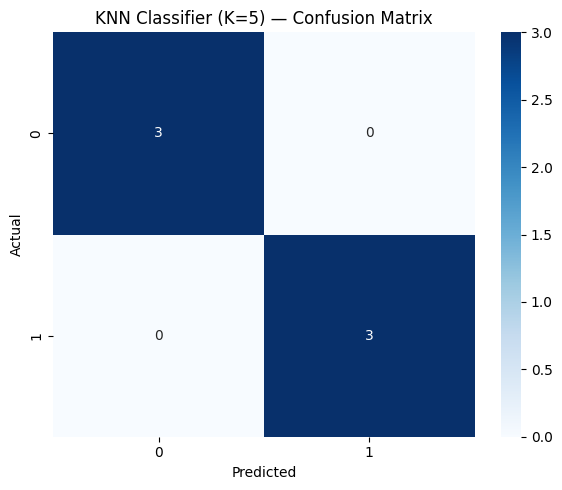

In [6]:
path = input("Enter CSV path (default: data.csv): ").strip() or "data.csv"
target = input("Enter target column: ").strip()

# Ask user: classification or regression
mode = input("Classification or Regression? (c/r): ").strip().lower()

X_train, X_test, y_train, y_test = load_and_preprocess(path, target)
k = input("Enter K (number of neighbors, default 5): ").strip()
k = int(k) if k else 5

if mode == 'r':
  model = KNeighborsRegressor(n_neighbors=k)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  evaluate_regression(y_test, y_pred, f"KNN Regressor (K={k})")
else:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  evaluate_classification(y_test, y_pred, f"KNN Classifier (K={k})")
